Loading QBDataCube_blended.csv
Loading RushingDataCube_blended.csv
Loading ReceivingDataCube_blended.csv
Loading DefenseDataCube_blended.csv
Loading KickingDataCube_blended.csv

Total careers found: 16,907




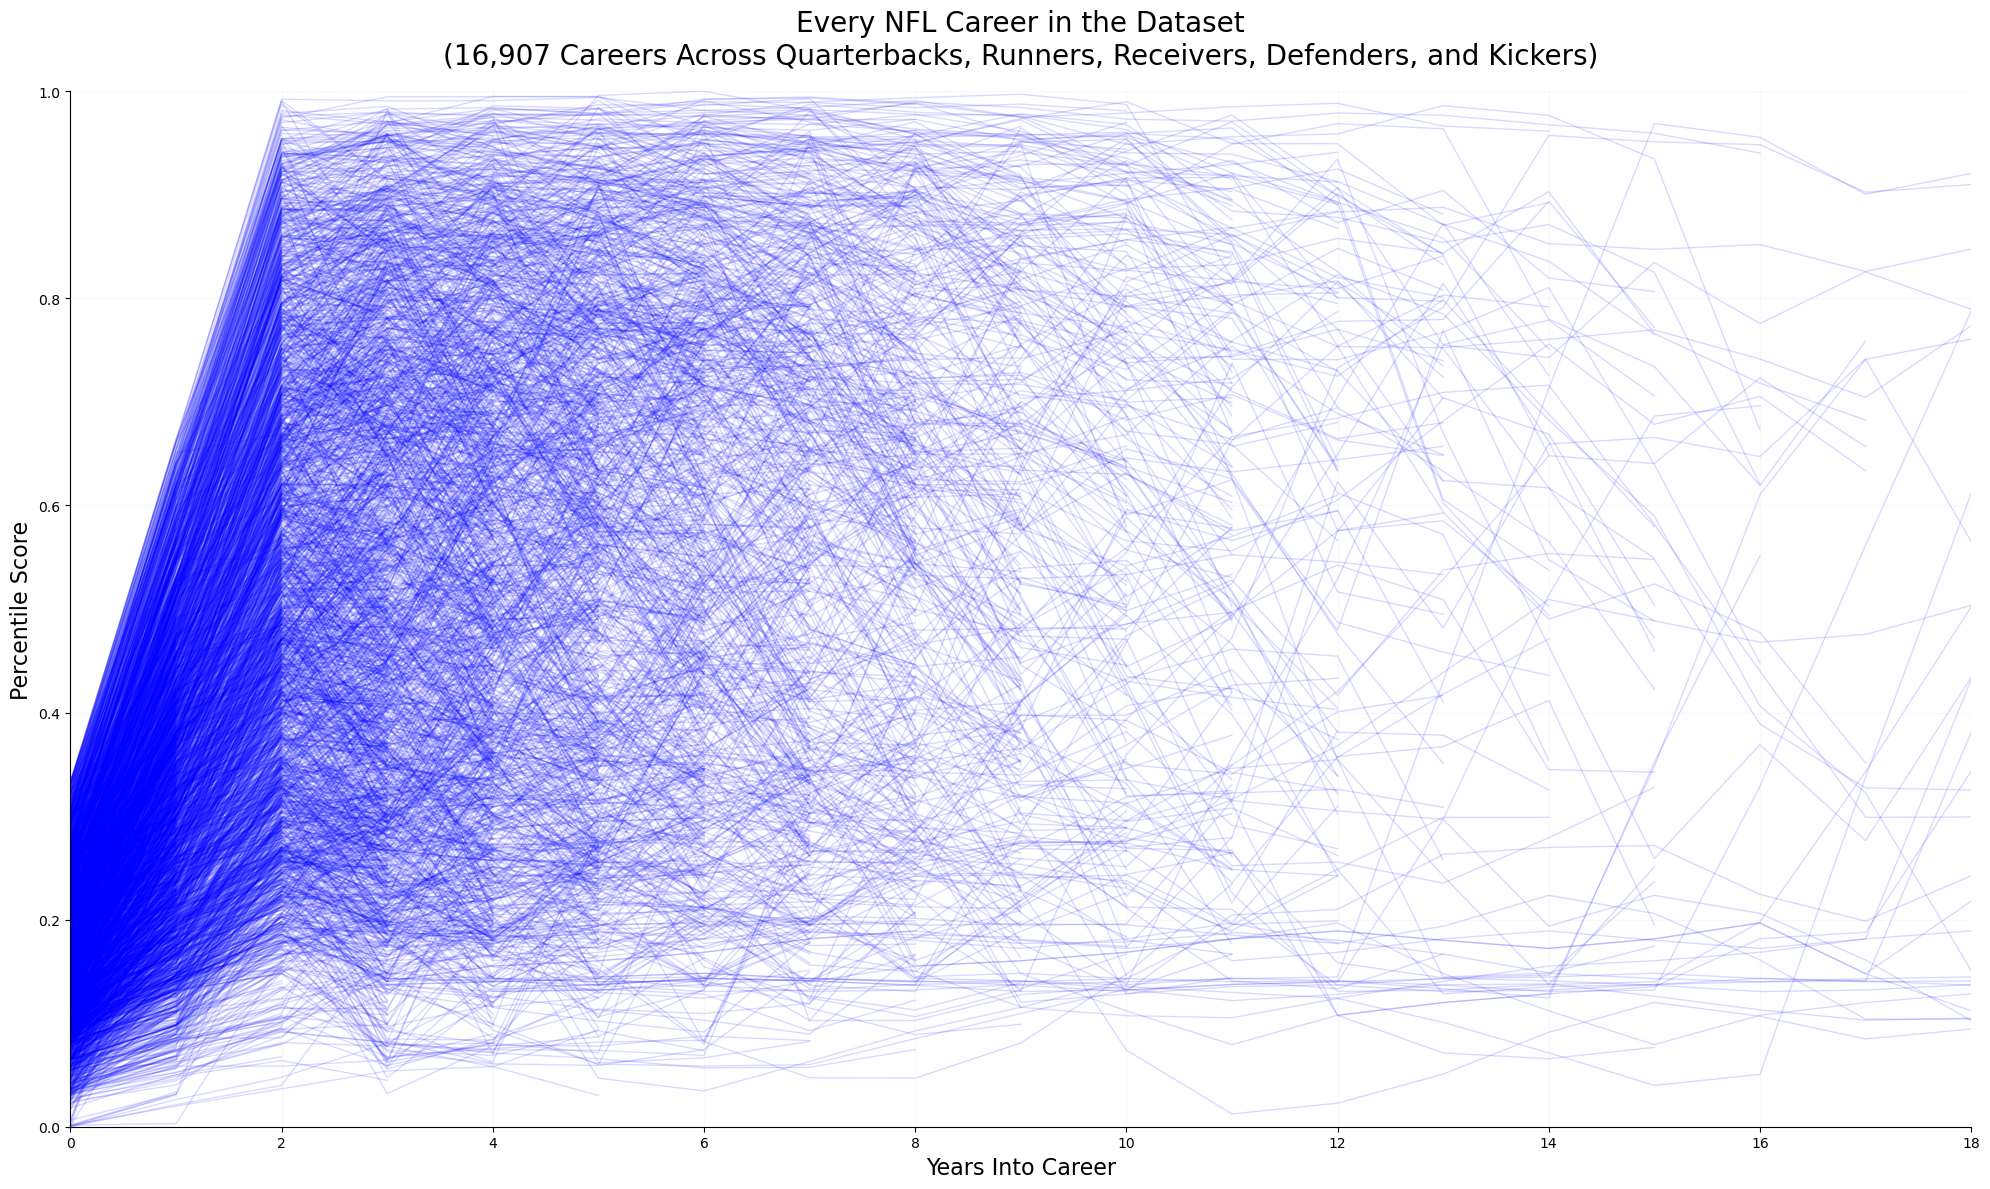

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import random

files = [
    "QBDataCube_blended.csv",
    "RushingDataCube_blended.csv",
    "ReceivingDataCube_blended.csv",
    "DefenseDataCube_blended.csv",
    "KickingDataCube_blended.csv"
]

career_list = []

for file in files:
    print(f"Loading {file}")
    df = pd.read_csv(file)
    df.columns = df.columns.str.strip()
    player_col = df.columns[0]
    if "YEAR" in df.columns:
        df = df.sort_values([player_col, "YEAR"])
    for _, player_data in df.groupby(player_col):
        scores = player_data["PERCENTILE"].values
        if len(scores) < 2:
            continue
        career_list.append(scores)

print(f"\nTotal careers found: {len(career_list):,}")
print()
print()

sample_size = min(3000, len(career_list))

sample_careers = random.sample(
    career_list,
    sample_size
)

# Now let's plot it all!

plt.figure(figsize=(20, 12))
for scores in sample_careers:
    plt.plot(range(len(scores)), scores, color="blue", alpha=0.15, linewidth=1)
plt.title(f"Every NFL Career in the Dataset\n({career_count:,} Careers Across Quarterbacks, Runners, Receivers, Defenders, and Kickers)", fontsize=20, pad=20)
plt.xlabel("Years Into Career", fontsize=16)
plt.ylabel("Percentile Score", fontsize=16)
plt.ylim(0, 1)
plt.grid(alpha=0.08)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.xlim(0, 18)
plt.tight_layout()
plt.show()